### Challenge:
Predict Flight Ticket Prices using a real-world dataset of Indian domestic flights (March–June 2019). Participants must build Machine Learning Models that can accurately estimate ticket prices based on features like airline, journey date, source, destination, duration, number of stops, and more.

### Problem Statement & Dataset Information
Airline ticket prices are highly dynamic and influenced by multiple factors such as time of journey, airline, source, destination, duration, and number of stops. For travelers, this unpredictability makes planning difficult, while for data scientists, it presents an exciting real-world problem. In this challenge, participants are tasked with building
machine learning models that can accurately predict flight ticket prices using the given dataset of domestic flights (March–June 2019). The objective is to apply data preprocessing, feature engineering, and model development to minimize prediction error and achieve the best performance metrics.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/IndianFlightdata - Sheet1.csv")
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
print(data.shape)

(10683, 11)


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB
None


In [ ]:
print(data.describe())

              Price
count  10683.000000
mean    9087.064121
std     4611.359167
min     1759.000000
25%     5277.000000
50%     8372.000000
75%    12373.000000
max    79512.000000


In [ ]:
airline_avg_price = data.groupby('Airline')['Price'].mean().sort_values(ascending=False)

# airline with the highest average price
highest_avg_price_airline = airline_avg_price.index[0]
highest_avg_price = airline_avg_price.iloc[0]

print(f"airline with the highest average flight ticket price is '{highest_avg_price_airline}' with an average price of ₹{round(highest_avg_price, 2)}.")

airline with the highest average flight ticket price is 'Jet Airways Business' with an average price of ₹58358.67.


In [ ]:
print(data.isnull().sum())

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [ ]:
print(data.head())

       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  


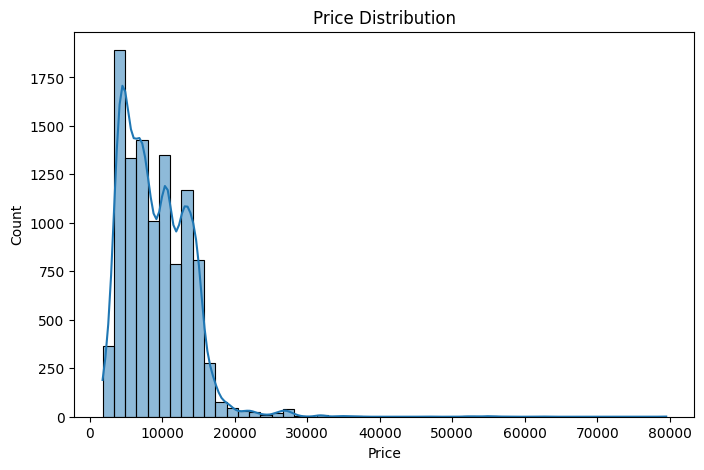

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

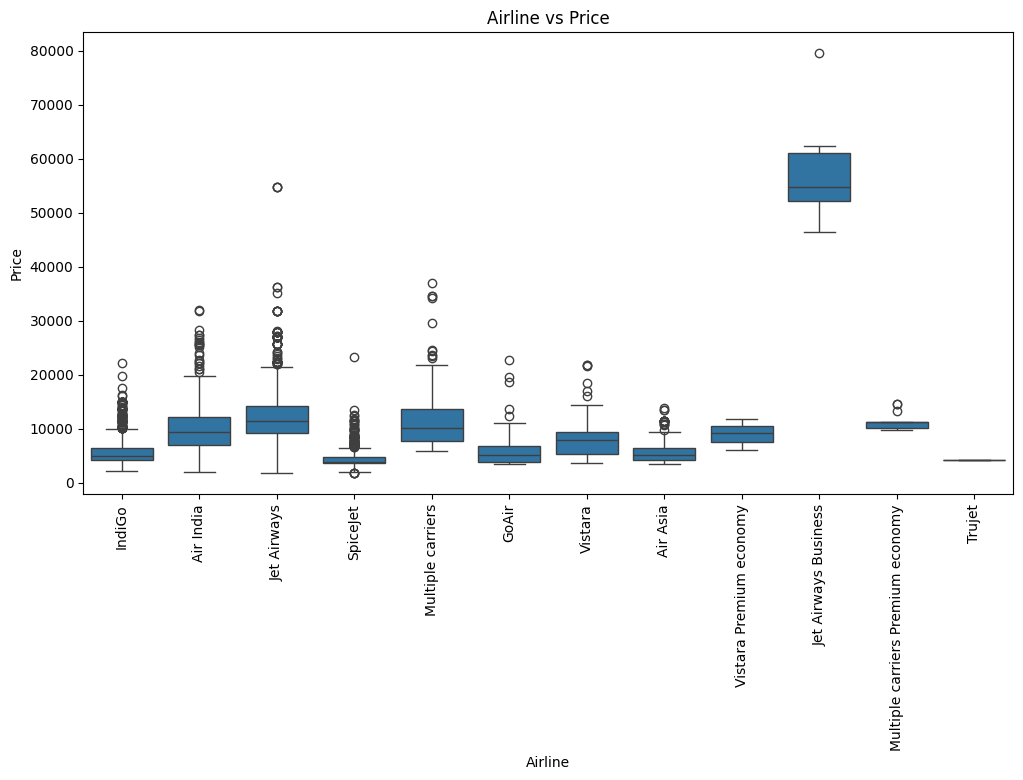

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Airline', y='Price', data = data)
plt.xticks(rotation=90)
plt.title('Airline vs Price')
plt.show()

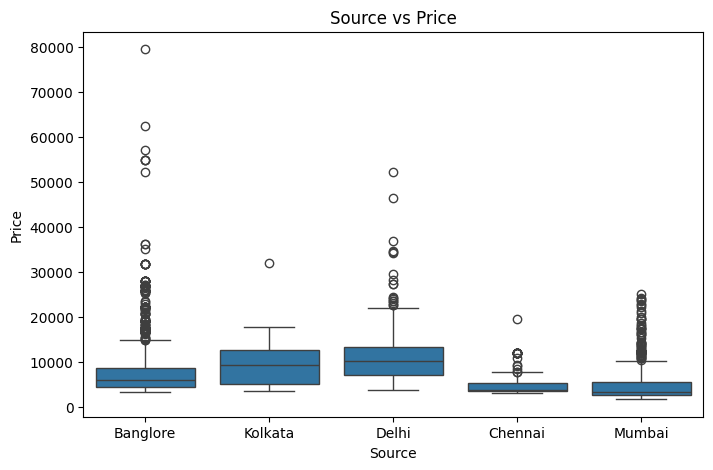

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Source', y='Price', data=data)
plt.title('Source vs Price')
plt.show()

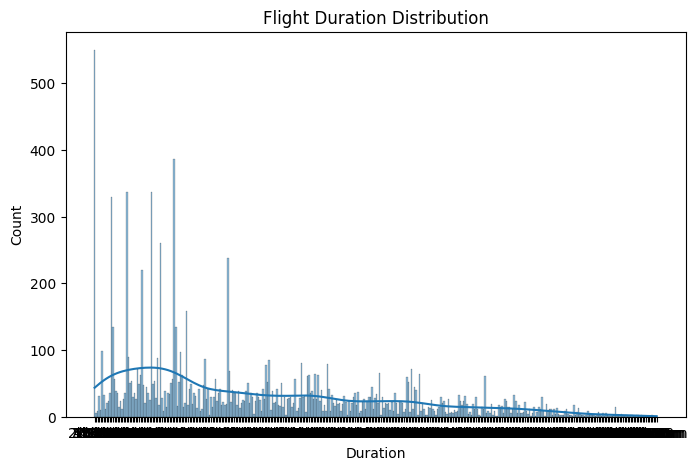

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Duration'], bins=50, kde=True)
plt.title('Flight Duration Distribution')
plt.show()

### Feature Engineering

In [ ]:
data['Journey_Day'] = pd.to_datetime(data['Date_of_Journey'], format='%d/%m/%Y').dt.day
data['Journey_Montth'] = pd.to_datetime(data['Date_of_Journey'], format='%d/%m/%Y').dt.month

In [ ]:
data.drop('Date_of_Journey', axis=1, inplace=True)

In [ ]:
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Minute'] = pd.to_datetime(data['Dep_Time']).dt.minute
data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0]).dt.hour
data['Arrival_Minute'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0]).dt.minute
data.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)

/tmp/ipython-input-2138412376.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
/tmp/ipython-input-2138412376.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dep_Minute'] = pd.to_datetime(data['Dep_Time']).dt.minute
/tmp/ipython-input-2138412376.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0]).dt.hour
/tmp/ipython-input-2138412376.py:4: UserWarning: Could not infer format, so each element will be parsed individually, fa

In [ ]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Montth,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
def duration_to_minutes(duration):
    h, m = 0, 0
    if 'h' in duration:
        h_part = duration.split('h')[0].strip()
        h = int(h_part)
        m_part = duration.split('h')[1].strip()
        if 'm' in m_part:
            m = int(m_part.replace('m','').strip())
    else:
        # Cases where only minutes present
        m = int(duration.replace('m','').strip())
    return h * 60 + m


In [ ]:
data['Duration'] = data['Duration'].apply(duration_to_minutes)


In [ ]:
# One-hot encode Airline, Source, Destination columns
data = pd.get_dummies(data, columns=['Airline', 'Source', 'Destination'], drop_first=True)

In [ ]:
data['Total_Stops'] = data['Total_Stops'].map({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3})
data.head()

,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Montth,Dep_Hour,Dep_Minute,Arrival_Hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,BLR → DEL,170,0.0,No info,3897,24,3,22,20,1,...,False,False,False,False,False,False,False,False,False,True
1,CCU → IXR → BBI → BLR,445,2.0,No info,7662,1,5,5,50,13,...,False,False,False,True,False,False,False,False,False,False
2,DEL → LKO → BOM → COK,1140,2.0,No info,13882,9,6,9,25,4,...,False,False,True,False,False,True,False,False,False,False
3,CCU → NAG → BLR,325,1.0,No info,6218,12,5,18,5,23,...,False,False,False,True,False,False,False,False,False,False
4,BLR → NAG → DEL,285,1.0,No info,13302,1,3,16,50,21,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# Convert all boolean columns to numeric (0 or 1)
data = data.astype({col: 'int' for col in data.columns if data[col].dtype == 'bool'})
data.head()

,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Montth,Dep_Hour,Dep_Minute,Arrival_Hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,BLR → DEL,170,0.0,No info,3897,24,3,22,20,1,...,0,0,0,0,0,0,0,0,0,1
1,CCU → IXR → BBI → BLR,445,2.0,No info,7662,1,5,5,50,13,...,0,0,0,1,0,0,0,0,0,0
2,DEL → LKO → BOM → COK,1140,2.0,No info,13882,9,6,9,25,4,...,0,0,1,0,0,1,0,0,0,0
3,CCU → NAG → BLR,325,1.0,No info,6218,12,5,18,5,23,...,0,0,0,1,0,0,0,0,0,0
4,BLR → NAG → DEL,285,1.0,No info,13302,1,3,16,50,21,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Handle missing values in Total_Stops
data['Total_Stops'] = data['Total_Stops'].fillna(0).astype(int)
data.head()

,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Montth,Dep_Hour,Dep_Minute,Arrival_Hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,BLR → DEL,170,0,No info,3897,24,3,22,20,1,...,0,0,0,0,0,0,0,0,0,1
1,CCU → IXR → BBI → BLR,445,2,No info,7662,1,5,5,50,13,...,0,0,0,1,0,0,0,0,0,0
2,DEL → LKO → BOM → COK,1140,2,No info,13882,9,6,9,25,4,...,0,0,1,0,0,1,0,0,0,0
3,CCU → NAG → BLR,325,1,No info,6218,12,5,18,5,23,...,0,0,0,1,0,0,0,0,0,0
4,BLR → NAG → DEL,285,1,No info,13302,1,3,16,50,21,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
data = data.drop(columns=['Route', 'Additional_Info'])

In [ ]:
data.head()

,Duration,Total_Stops,Price,Journey_Day,Journey_Montth,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,170,0,3897,24,3,22,20,1,10,0,...,0,0,0,0,0,0,0,0,0,1
1,445,2,7662,1,5,5,50,13,15,1,...,0,0,0,1,0,0,0,0,0,0
2,1140,2,13882,9,6,9,25,4,25,0,...,0,0,1,0,0,1,0,0,0,0
3,325,1,6218,12,5,18,5,23,30,0,...,0,0,0,1,0,0,0,0,0,0
4,285,1,13302,1,3,16,50,21,35,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X = data.drop('Price', axis=1)
y = data['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Train samples: 8546, Test samples: 2137


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


MAE: 1179.3068463638608
RMSE: 2019.0534353184628
R² Score: 0.8073812458427565


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [150, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluate on Test Set
y_pred = best_model.predict(X_test)

print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Test R² Score: {r2_score(y_test, y_pred):.4f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 300}
Test MAE: 1141.10
Test RMSE: 1902.95
Test R² Score: 0.8289
